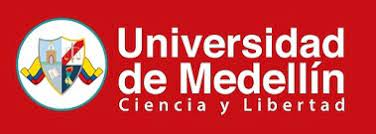

***
<!--NAVIGATION-->
< [← Otras notas en Python](1.1_Python_repaso_y_Otros.ipynb) | [Contenido](Index.ipynb) >
***

# INTRODUCCIÓN PANDAS

En Computación y Ciencia de datos, pandas es una biblioteca de software escrita como extensión de NumPy para manipulación y análisis de datos para el lenguaje de programación Python. En particular, ofrece estructuras de datos y operaciones para manipular tablas numéricas y series temporales. Es un software libre distribuido bajo la licencia BSD versión tres cláusulas. El nombre deriva del término "datos de panel", término de econometría que designa datos que combinan una dimensión temporal con otra dimensión transversal.

A continuación, vamos a iniciar la revisión de algunas de las funciones más utilizadas en pandas. Primero, el inicio de carga de datos.

In [3]:
import numpy as np
import pandas as pd

dates = pd.date_range('20130101', periods=6)
dates

df = pd.DataFrame(
    np.random.randn(6, 4), 
    index=dates, 
    columns=["carro","casa","beca","yate"]
)
df

,carro,casa,beca,yate
2013-01-01,1.105135,-1.072009,0.287260,0.320943
2013-01-02,-1.223966,0.810955,-0.134067,-0.147597
2013-01-03,-0.119492,-0.212026,0.235568,2.176477
2013-01-04,0.681461,1.011525,0.540275,-0.060364
2013-01-05,0.922640,-0.312008,-0.159125,0.842818
2013-01-06,0.795417,0.789539,-0.538472,-1.052391


Se crea un dataframe con los datos generados. El dataframe es una estructura de pandas, que consiste en una organización de filas y columnas; en otras palabras, es una tabla


In [3]:
df2 = pd.DataFrame(
    {
        'A': 1.,
        'B': pd.Timestamp('20130102'),
        'C': pd.Series(1, index=list(range(5)), dtype='float32'),
        'D': np.array([6] * 5, dtype='int32'),
        'E': pd.Categorical(["test", "train", "test", "train","test"]),
        'F': 'foo'
    }
)
print(df2)

     A          B    C  D      E    F
0  1.0 2013-01-02  1.0  6   test  foo
1  1.0 2013-01-02  1.0  6  train  foo
2  1.0 2013-01-02  1.0  6   test  foo
3  1.0 2013-01-02  1.0  6  train  foo
4  1.0 2013-01-02  1.0  6   test  foo


Esta función $.head()$ permite observar la parte superior del dataframe

In [4]:
df.head()

,carro,casa,beca,yate
2013-01-01,1.138864,-1.395980,1.110032,-0.106356
2013-01-02,-0.563106,-0.870220,0.990681,0.362715
2013-01-03,-0.203001,-0.122011,0.627251,-0.288200
2013-01-04,-0.021935,0.442613,0.865543,-1.629537
2013-01-05,0.092359,0.431074,-0.947343,0.796397


Por su parte, el $.tail$ nos muestra la parte inferior del dataframe

In [5]:
df.tail(3)

,carro,casa,beca,yate
2013-01-04,-0.021935,0.442613,0.865543,-1.629537
2013-01-05,0.092359,0.431074,-0.947343,0.796397
2013-01-06,-1.186444,0.786628,-0.621487,0.001132


Se revisa el indice de la tabla

In [6]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

Con esta función $.columns$ se pueden observar los nombres (encabezados) del dataframe

In [7]:
df.columns

Index(['carro', 'casa', 'beca', 'yate'], dtype='object')

La función $.describe$ nos ofrece una serie de indicadores estadísticos

In [8]:
df.describe()["casa"]

count    6.000000
mean    -0.121316
std      0.852425
min     -1.395980
25%     -0.683167
50%      0.154531
75%      0.439728
max      0.786628
Name: casa, dtype: float64

la funcion $.info()$ nos brinda un vistazo general de las condiciones de dataframe

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6 entries, 2013-01-01 to 2013-01-06
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carro   6 non-null      float64
 1   casa    6 non-null      float64
 2   beca    6 non-null      float64
 3   yate    6 non-null      float64
dtypes: float64(4)
memory usage: 240.0 bytes


A continuación, vamos a ordenar la data por una columna especifica

In [10]:
df.sort_values(by='casa')

,carro,casa,beca,yate
2013-01-01,1.138864,-1.395980,1.110032,-0.106356
2013-01-02,-0.563106,-0.870220,0.990681,0.362715
2013-01-03,-0.203001,-0.122011,0.627251,-0.288200
2013-01-05,0.092359,0.431074,-0.947343,0.796397
2013-01-04,-0.021935,0.442613,0.865543,-1.629537
2013-01-06,-1.186444,0.786628,-0.621487,0.001132


Se chequea una variable especifica del dataframe

In [11]:
df['casa']

2013-01-01   -1.395980
2013-01-02   -0.870220
2013-01-03   -0.122011
2013-01-04    0.442613
2013-01-05    0.431074
2013-01-06    0.786628
Freq: D, Name: casa, dtype: float64

Revisemos una parte de la matriz, desde la columna 0 a la 3

In [12]:
df[0:3]

,carro,casa,beca,yate
2013-01-01,1.138864,-1.395980,1.110032,-0.106356
2013-01-02,-0.563106,-0.870220,0.990681,0.362715
2013-01-03,-0.203001,-0.122011,0.627251,-0.288200


La función $.loc$ permite acceder a un grupo de filas y columnas por etiqueta (s) o una matriz booleana.

In [4]:
df.loc[dates[0]]

carro    1.105135
casa    -1.072009
beca     0.287260
yate     0.320943
Name: 2013-01-01 00:00:00, dtype: float64

In [14]:
df.loc[:, ['casa', 'carro']]

,casa,carro
2013-01-01,-1.395980,1.138864
2013-01-02,-0.870220,-0.563106
2013-01-03,-0.122011,-0.203001
2013-01-04,0.442613,-0.021935
2013-01-05,0.431074,0.092359
2013-01-06,0.786628,-1.186444


In [15]:
df.loc['20130102':'20130104']

,carro,casa,beca,yate
2013-01-02,-0.563106,-0.870220,0.990681,0.362715
2013-01-03,-0.203001,-0.122011,0.627251,-0.288200
2013-01-04,-0.021935,0.442613,0.865543,-1.629537


Por otro lado, la función $.iloc$ es una indización basada puramente en lugares enteros para la selección por posición.

In [6]:
df.iloc[3]

carro    0.681461
casa     1.011525
beca     0.540275
yate    -0.060364
Name: 2013-01-04 00:00:00, dtype: float64

In [17]:
df.iloc[[1, 2, 4], [0, 2]]

,carro,beca
2013-01-02,-0.563106,0.990681
2013-01-03,-0.203001,0.627251
2013-01-05,0.092359,-0.947343


In [18]:
df.iloc[1:3, :]

,carro,casa,beca,yate
2013-01-02,-0.563106,-0.870220,0.990681,0.362715
2013-01-03,-0.203001,-0.122011,0.627251,-0.288200


In [19]:
df.iloc[:, 1:3]

,casa,beca
2013-01-01,-1.395980,1.110032
2013-01-02,-0.870220,0.990681
2013-01-03,-0.122011,0.627251
2013-01-04,0.442613,0.865543
2013-01-05,0.431074,-0.947343
2013-01-06,0.786628,-0.621487


Luego, miremos algunos filtros simples con Pandas

In [21]:
df[df.casa > 0]

,carro,casa,beca,yate
2013-01-04,-0.021935,0.442613,0.865543,-1.629537
2013-01-05,0.092359,0.431074,-0.947343,0.796397
2013-01-06,-1.186444,0.786628,-0.621487,0.001132


In [22]:
df[df > 0]

,carro,casa,beca,yate
2013-01-01,1.138864,NaN,1.110032,NaN
2013-01-02,NaN,NaN,0.990681,0.362715
2013-01-03,NaN,NaN,0.627251,NaN
2013-01-04,NaN,0.442613,0.865543,NaN
2013-01-05,0.092359,0.431074,NaN,0.796397
2013-01-06,NaN,0.786628,NaN,0.001132


La función $.at$ permite acceder a un solo valor para un par de etiquetas de fila / columna.

In [7]:
df.at[dates[0], 'casa'] = 0
df

,carro,casa,beca,yate
2013-01-01,1.105135,0.000000,0.287260,0.320943
2013-01-02,-1.223966,0.810955,-0.134067,-0.147597
2013-01-03,-0.119492,-0.212026,0.235568,2.176477
2013-01-04,0.681461,1.011525,0.540275,-0.060364
2013-01-05,0.922640,-0.312008,-0.159125,0.842818
2013-01-06,0.795417,0.789539,-0.538472,-1.052391



Mientras que la función $.iat$ facilita acceder a un solo valor para un par de fila / columna por posición de entero.

In [8]:
df.iat[0, 1] = 0
df

,carro,casa,beca,yate
2013-01-01,1.105135,0.000000,0.287260,0.320943
2013-01-02,-1.223966,0.810955,-0.134067,-0.147597
2013-01-03,-0.119492,-0.212026,0.235568,2.176477
2013-01-04,0.681461,1.011525,0.540275,-0.060364
2013-01-05,0.922640,-0.312008,-0.159125,0.842818
2013-01-06,0.795417,0.789539,-0.538472,-1.052391


Se genera un $.array$ determinado y se incluye en el dataframe de trabajo

In [26]:
df.loc[:, 'carro'] = np.array([5] * len(df))
df

,carro,casa,beca,yate
2013-01-01,5,0.000000,1.110032,-0.106356
2013-01-02,5,-0.870220,0.990681,0.362715
2013-01-03,5,-0.122011,0.627251,-0.288200
2013-01-04,5,0.442613,0.865543,-1.629537
2013-01-05,5,0.431074,-0.947343,0.796397
2013-01-06,5,0.786628,-0.621487,0.001132


Estadísticos por columna

In [27]:
df.mean()

carro    5.000000
casa     0.111347
beca     0.337446
yate    -0.143975
dtype: float64

Mostrar el conjunto de datos

In [28]:
df

,carro,casa,beca,yate
2013-01-01,5,0.000000,1.110032,-0.106356
2013-01-02,5,-0.870220,0.990681,0.362715
2013-01-03,5,-0.122011,0.627251,-0.288200
2013-01-04,5,0.442613,0.865543,-1.629537
2013-01-05,5,0.431074,-0.947343,0.796397
2013-01-06,5,0.786628,-0.621487,0.001132


In [29]:
df.mean(1)

2013-01-01    1.500919
2013-01-02    1.370794
2013-01-03    1.304260
2013-01-04    1.169655
2013-01-05    1.320032
2013-01-06    1.291568
Freq: D, dtype: float64

In [30]:
#Merging section.
df = pd.DataFrame(np.random.randn(10, 4))
df

,0,1,2,3
0,0.684355,1.132561,2.233088,0.693409
1,-0.371621,-0.572696,-0.159828,-1.366417
2,-0.660801,0.308939,-0.835837,0.402071
3,-0.136143,-0.470864,-0.656126,1.693449
4,1.603120,0.193113,-0.198375,0.203269
5,1.076744,-0.896218,-1.057657,-1.046759
6,1.095963,-0.422293,-0.982787,-0.521101
7,-0.937261,-0.102704,2.074346,-0.759062
8,0.668815,-1.220886,0.319640,0.780338
9,1.276758,1.505104,0.819206,-0.311830


Creación de dataframe

In [31]:
left = pd.DataFrame({'key': ['foo', 'foo'], 'lval': [1, 2]})
right = pd.DataFrame({'key': ['food', 'foo'], 'rval': [4, 5]})

left

,key,lval
0,foo,1
1,foo,2


In [32]:
right

,key,rval
0,food,4
1,foo,5


Ahora, se usará una función que nos permita combinar los dataframe

In [33]:
pd.merge(left, right, on='key',how="right")

,key,lval,rval
0,food,NaN,4
1,foo,1.0,5
2,foo,2.0,5


Otra función a tener en cuenta es, .append que posibilita el agregar nuevas columnas a un dataframe

In [34]:

df = pd.DataFrame(np.random.randn(8, 4), columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
0,-0.103940,1.202173,0.613684,0.800597
1,1.795470,-0.148487,-0.353158,-0.559321
2,0.370793,0.926130,0.529238,-0.246812
3,-0.121163,-1.177043,1.506179,0.424669
4,-1.277548,-0.676835,-0.544927,0.227128
5,0.904934,0.531727,-1.358820,-0.103065
6,1.517540,2.494850,-0.392722,-1.251837
7,-3.098262,0.431167,-0.113713,1.251219


In [35]:
s = df.iloc[3]
s

A   -0.121163
B   -1.177043
C    1.506179
D    0.424669
Name: 3, dtype: float64

In [36]:
df=df.append(s, ignore_index=True)
df

,A,B,C,D
0,-0.103940,1.202173,0.613684,0.800597
1,1.795470,-0.148487,-0.353158,-0.559321
2,0.370793,0.926130,0.529238,-0.246812
3,-0.121163,-1.177043,1.506179,0.424669
4,-1.277548,-0.676835,-0.544927,0.227128
5,0.904934,0.531727,-1.358820,-0.103065
6,1.517540,2.494850,-0.392722,-1.251837
7,-3.098262,0.431167,-0.113713,1.251219
8,-0.121163,-1.177043,1.506179,0.424669


La funciónn groupby facilita el realizar sumarización por grupos

In [38]:
df.groupby('A').sum()

,B,C,D
A,,,
-3.098262,0.431167,-0.113713,1.251219
-1.277548,-0.676835,-0.544927,0.227128
-0.121163,-2.354087,3.012358,0.849337
-0.103940,1.202173,0.613684,0.800597
0.370793,0.926130,0.529238,-0.246812
0.904934,0.531727,-1.358820,-0.103065
1.517540,2.494850,-0.392722,-1.251837
1.795470,-0.148487,-0.353158,-0.559321


In [39]:
df.groupby(['A', 'B']).sum()

,,C,D
A,B,,
-3.098262,0.431167,-0.113713,1.251219
-1.277548,-0.676835,-0.544927,0.227128
-0.121163,-1.177043,3.012358,0.849337
-0.103940,1.202173,0.613684,0.800597
0.370793,0.926130,0.529238,-0.246812
0.904934,0.531727,-1.358820,-0.103065
1.517540,2.494850,-0.392722,-1.251837
1.795470,-0.148487,-0.353158,-0.559321


La función $.pivot$ se utiliza para transponer una dataframe; es decir, organizar la tabla de otra forma

In [40]:
#Pivot Tables
df = pd.DataFrame({'A': ['one', 'one', 'two', 'three'] * 3,
                       'B': ['A', 'B', 'C'] * 4,
                       'C': ['foo', 'foo', 'foo', 'bar', 'bar', 'bar'] * 2,
                       'D': np.random.randn(12),
                       'E': np.random.randn(12)})
df

,A,B,C,D,E
0,one,A,foo,0.646715,0.151459
1,one,B,foo,-1.768236,-0.306671
2,two,C,foo,-0.899926,-0.753451
3,three,A,bar,-0.345030,-0.085027
4,one,B,bar,-0.506174,0.719502
5,one,C,bar,1.382177,-0.564467
6,two,A,foo,1.999544,-0.083582
7,three,B,foo,0.054269,-1.420231
8,one,C,foo,0.427822,-0.902731
9,one,A,bar,0.572227,1.369031


In [41]:
pd.pivot_table(df, values='D', index=['A','B'], columns=['C'])

C             bar       foo
A     B                    
one   A  0.572227  0.646715
      B -0.506174 -1.768236
      C  1.382177  0.427822
three A -0.345030       NaN
      B       NaN  0.054269
      C -0.315373       NaN
two   A       NaN  1.999544
      B  0.966200       NaN
      C       NaN -0.899926

La función $transpose$ facilita el trabajar con matrices y realizar la transpuesta

In [42]:
d1 = {'col1': [1, 2], 'col2': [3, 4]}
df1 = pd.DataFrame(data=d1)
df1

,col1,col2
0,1,3
1,2,4


In [43]:
df1_transposed = df1.T
df1_transposed

,0,1
col1,1,2
col2,3,4


In [44]:
df1.transpose()

,0,1
col1,1,2
col2,3,4


****

****

#### La función concat
La función concat() (en el espacio de nombres principal de los pandas) hace todo el trabajo pesado de realizar operaciones de concatenación a lo largo de un eje mientras realiza la lógica de conjunto opcional (unión o intersección) de los índices (si los hay) en los otros ejes. Tenga en cuenta que digo "si lo hay" porque solo hay un único posible eje de concatenación para la Serie.

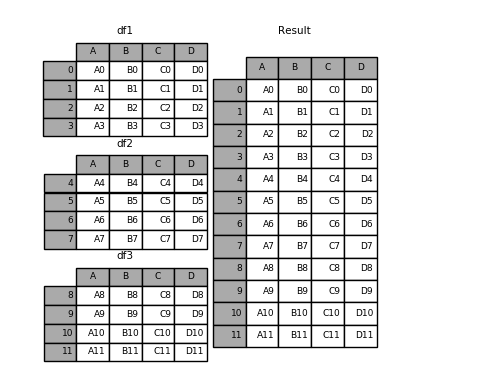

In [10]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2', 'A3'],
                       'B': ['B0', 'B1', 'B2', 'B3'],
                       'C': ['C0', 'C1', 'C2', 'C3'],
                       'D': ['D0', 'D1', 'D2', 'D3']},
                      index=[0, 1, 2, 3])


df2 = pd.DataFrame({'A': ['A4', 'A5', 'A6', 'A7'],
                        'B': ['B4', 'B5', 'B6', 'B7'],
                        'C': ['C4', 'C5', 'C6', 'C7'],
                        'D': ['D4', 'D5', 'D6', 'D7']},
                       index=[4, 5, 6, 7])


df3 = pd.DataFrame({'A': ['A8', 'A9', 'A10', 'A11'],
                    'B': ['B8', 'B9', 'B10', 'B11'],
                       'C': ['C8', 'C9', 'C10', 'C11'],
                       'D': ['D8', 'D9', 'D10', 'D11']},
                      index=[8, 9, 10, 11])


frames = [df1, df2, df3]

result = pd.concat(frames)
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


Se incluiran unas jerarquias adicionales

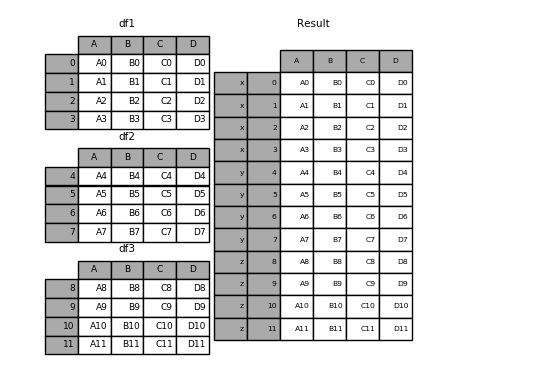

In [47]:
result = pd.concat(frames, keys=['x', 'y', 'z'])
result

A    B    C    D
x 0    A0   B0   C0   D0
  1    A1   B1   C1   D1
  2    A2   B2   C2   D2
  3    A3   B3   C3   D3
y 4    A4   B4   C4   D4
  5    A5   B5   C5   D5
  6    A6   B6   C6   D6
  7    A7   B7   C7   D7
z 8    A8   B8   C8   D8
  9    A9   B9   C9   D9
  10  A10  B10  C10  D10
  11  A11  B11  C11  D11

Como puede ver, el índice del objeto resultante tiene un índice jerárquico. Esto significa que ahora podemos seleccionar cada fragmento por clave:

In [48]:
result.loc['y']

,A,B,C,D
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7


#### Organizar los ejes
Al pegar varios DataFrames, puede elegir cómo manejar los otros ejes (aparte del que está concatenado). Esto se puede hacer de las siguientes dos maneras:
*Toma la unión de todos ellos, join = 'outer'. Esta es la opción predeterminada, ya que da como resultado una pérdida de información cero.
*Toma la intersección,  join = 'inner'.
Aquí hay un ejemplo de cada uno de estos métodos. En primer lugar, el comportamiento por defecto unirse = 'externo':


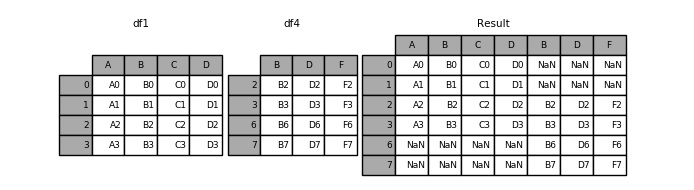

In [11]:
df4 = pd.DataFrame({'B': ['B2', 'B3', 'B6', 'B7'],
                     'D': ['D2', 'D3', 'D6', 'D7'],
                      'F': ['F2', 'F3', 'F6', 'F7']},
                      index=[2, 3, 6, 7])


result = pd.concat([df1, df4], axis=1, sort=False)
result

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3
6,NaN,NaN,NaN,NaN,B6,D6,F6
7,NaN,NaN,NaN,NaN,B7,D7,F7


: 

#### Inner join

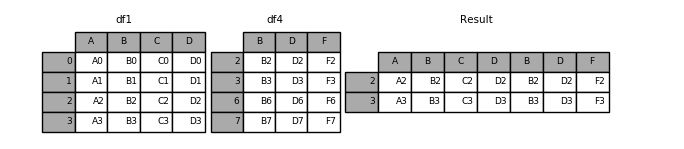

In [50]:
result = pd.concat([df1, df4], axis=1, join='inner')
result

,A,B,C,D,B,D,F
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


Por último, supongamos que solo queremos reutilizar el índice exacto del DataFrame original

In [51]:
result = pd.concat([df1, df4], axis=1).reindex(df1.index)
result

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


Del mismo modo, podríamos indexar antes de la concatenación

In [52]:
pd.concat([df1, df4.reindex(df1.index)], axis=1)

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


#### Concatenando usando append

Un atajo útil para concat() son los métodos de instancia de append() en Series y DataFrame. Estos métodos en realidad son anteriores al concat. Ellos concatenan a lo largo del eje = 0, es decir, el índice..

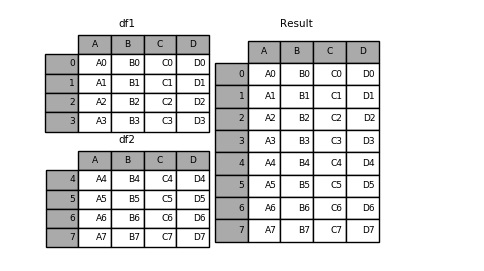

In [53]:
result = df1.append(df2)
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7


En el caso de DataFrame, los índices deben estar separados, pero las columnas no tienen estar así

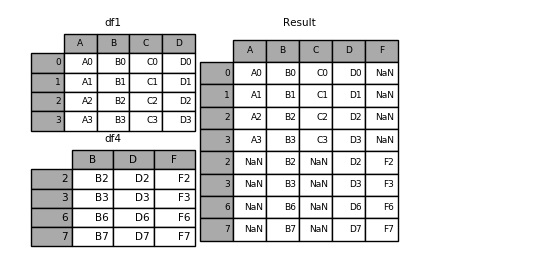

In [54]:
result = df1.append(df4, sort=False)
result

,A,B,C,D,F
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
2,NaN,B2,NaN,D2,F2
3,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


append() puede tomar varios objetos para concatenar

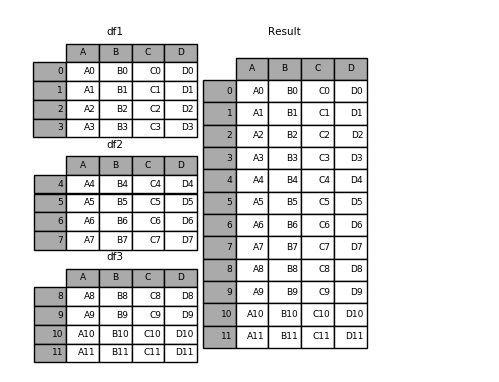

In [55]:
result = df1.append([df2, df3])
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


### Ignorar los índices en el eje de concatenación.

Para los objetos DataFrame que no tienen un índice significativo, es posible que desee agregarlos e ignorar el hecho de que pueden tener índices superpuestos. Para hacer esto, usa el argumento ignore_index.

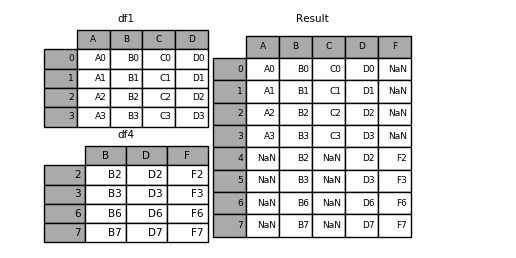

In [56]:
result = pd.concat([df1, df4], ignore_index=True, sort=False)
result

,A,B,C,D,F
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
4,NaN,B2,NaN,D2,F2
5,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


Otra forma validad para DataFrame $.append()$

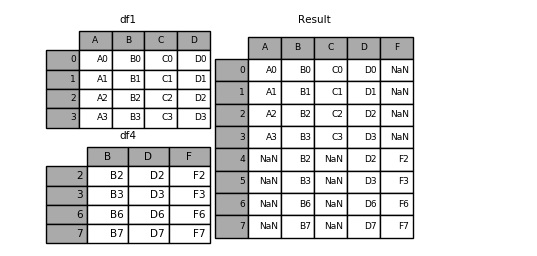

In [57]:
result = df1.append(df4, ignore_index=True, sort=False)
result

,A,B,C,D,F
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
4,NaN,B2,NaN,D2,F2
5,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


#### Concatenando con ndims mixtos
Puede concatenar una mezcla de objetos Series y DataFrame. La serie se transformará a DataFrame con el nombre de la columna, como el nombre de la serie

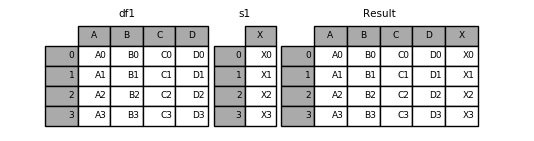

In [58]:
s1 = pd.Series(['X0', 'X1', 'X2', 'X3'], name='X')

result = pd.concat([df1, s1], axis=1)
result

,A,B,C,D,X
0,A0,B0,C0,D0,X0
1,A1,B1,C1,D1,X1
2,A2,B2,C2,D2,X2
3,A3,B3,C3,D3,X3



Si se pasan series sin nombre, se numerarán consecutivamente.

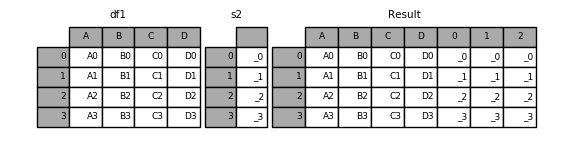

In [59]:
s2 = pd.Series(['_0', '_1', '_2', '_3'])

result = pd.concat([df1, s2, s2, s2], axis=1)

result

,A,B,C,D,0,1,2
0,A0,B0,C0,D0,_0,_0,_0
1,A1,B1,C1,D1,_1,_1,_1
2,A2,B2,C2,D2,_2,_2,_2
3,A3,B3,C3,D3,_3,_3,_3


Al pasar ignore_index = True, se eliminarán todas las referencias de nombres.

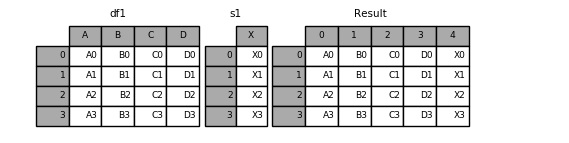

In [60]:
result = pd.concat([df1, s1], axis=1, ignore_index=True)
result

,0,1,2,3,4
0,A0,B0,C0,D0,X0
1,A1,B1,C1,D1,X1
2,A2,B2,C2,D2,X2
3,A3,B3,C3,D3,X3


### Más concatenando con llaves de grupo.
Un uso bastante común del argumento de llaves es anular los nombres de columna al crear un nuevo DataFrame basado en una serie existente. Observe cómo el comportamiento predeterminado consiste en dejar que el DataFrame resultante herede el nombre de la Serie principal, cuando existían.

In [61]:
s3 = pd.Series([0, 1, 2, 3], name='foo')

s4 = pd.Series([0, 1, 2, 3])

s5 = pd.Series([0, 1, 4, 5])

pd.concat([s3, s4, s5], axis=1)

,foo,0,1
0,0,0,0
1,1,1,1
2,2,2,4
3,3,3,5


A través del argumento llaves podemos anular los nombres de columna existentes.

In [62]:
pd.concat([s3, s4, s5], axis=1, keys=['red', 'blue', 'yellow'])

,red,blue,yellow
0,0,0,0
1,1,1,1
2,2,2,4
3,3,3,5


Consideremos una variación del primer ejemplo presentado

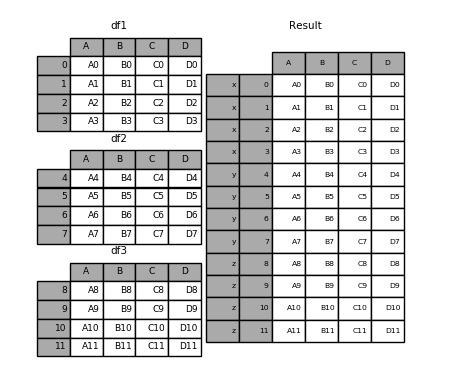

In [63]:
result = pd.concat(frames, keys=['x', 'y', 'z'])
result

A    B    C    D
x 0    A0   B0   C0   D0
  1    A1   B1   C1   D1
  2    A2   B2   C2   D2
  3    A3   B3   C3   D3
y 4    A4   B4   C4   D4
  5    A5   B5   C5   D5
  6    A6   B6   C6   D6
  7    A7   B7   C7   D7
z 8    A8   B8   C8   D8
  9    A9   B9   C9   D9
  10  A10  B10  C10  D10
  11  A11  B11  C11  D11

También puede pasar un dict a concat, en cuyo caso las llaves dict se usarán para el argumento de las claves (a menos que se especifiquen otras llaves).

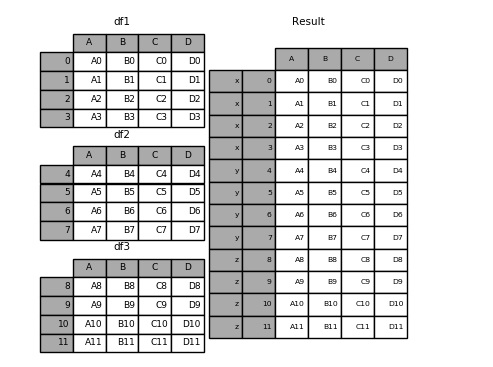

In [64]:
pieces = {'x': df1, 'y': df2, 'z': df3}

result = pd.concat(pieces)
result

A    B    C    D
x 0    A0   B0   C0   D0
  1    A1   B1   C1   D1
  2    A2   B2   C2   D2
  3    A3   B3   C3   D3
y 4    A4   B4   C4   D4
  5    A5   B5   C5   D5
  6    A6   B6   C6   D6
  7    A7   B7   C7   D7
z 8    A8   B8   C8   D8
  9    A9   B9   C9   D9
  10  A10  B10  C10  D10
  11  A11  B11  C11  D11

Otras opción, tomando un subconjunto

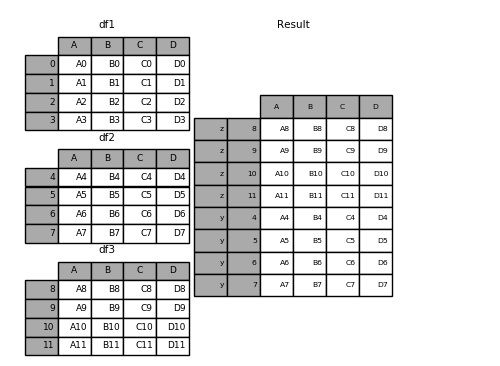

In [66]:
result = pd.concat(pieces, keys=['z', 'y'])
result

A    B    C    D
z 8    A8   B8   C8   D8
  9    A9   B9   C9   D9
  10  A10  B10  C10  D10
  11  A11  B11  C11  D11
y 4    A4   B4   C4   D4
  5    A5   B5   C5   D5
  6    A6   B6   C6   D6
  7    A7   B7   C7   D7

El MultiIndex creado tiene niveles que se construyen a partir de las llaves pasadas y el índice de las piezas del DataFrame

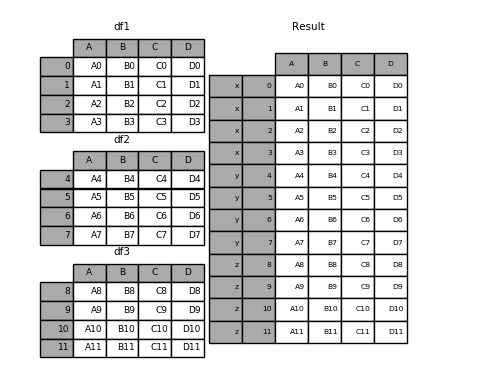

In [67]:
result = pd.concat(pieces, keys=['x', 'y', 'z'],
                   levels=[['z', 'y', 'x', 'w']],
                      names=['group_key'])
result

A    B    C    D
group_key                       
x         0    A0   B0   C0   D0
          1    A1   B1   C1   D1
          2    A2   B2   C2   D2
          3    A3   B3   C3   D3
y         4    A4   B4   C4   D4
          5    A5   B5   C5   D5
          6    A6   B6   C6   D6
          7    A7   B7   C7   D7
z         8    A8   B8   C8   D8
          9    A9   B9   C9   D9
          10  A10  B10  C10  D10
          11  A11  B11  C11  D11

In [68]:
result.index.levels

FrozenList([['z', 'y', 'x', 'w'], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]])

#### Anexando filas a un DataFrame
Si bien no es especialmente eficiente (ya que se debe crear un nuevo objeto), puede agregar una sola fila a un DataFrame pasando una serie o un dictado para agregar, que devuelve un nuevo DataFrame como se indicó anteriormente.

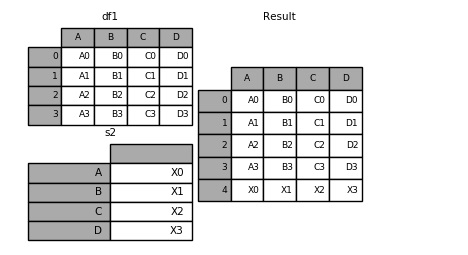

In [69]:
s2 = pd.Series(['X0', 'X1', 'X2', 'X3'], index=['A', 'B', 'C', 'D'])

result = df1.append(s2, ignore_index=True)
result


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,X0,X1,X2,X3


También puede pasar una lista de dicts o series:

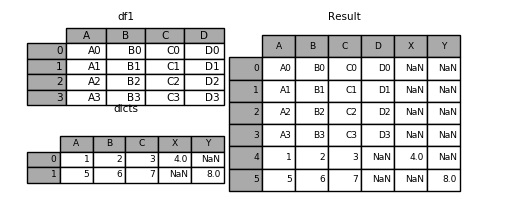

In [70]:
dicts = [{'A': 1, 'B': 2, 'C': 3, 'X': 4},
           {'A': 5, 'B': 6, 'C': 7, 'Y': 8}]


result = df1.append(dicts, ignore_index=True, sort=False)
result

,A,B,C,D,X,Y
0,A0,B0,C0,D0,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN
2,A2,B2,C2,D2,NaN,NaN
3,A3,B3,C3,D3,NaN,NaN
4,1,2,3,NaN,4.0,NaN
5,5,6,7,NaN,NaN,8.0


### Estilo de base de datos DataFrame o Series con nombre joining/merging

pandas tiene operaciones de unión en memoria de alto rendimiento con todas las funciones idiomáticamente muy similares a las bases de datos relacionales como SQL. Estos métodos tienen un rendimiento significativamente mejor (en algunos casos, más de un orden de magnitud mejor) que otras implementaciones de código abierto (como base :: merge.data.frame en R). La razón de esto es el cuidadoso diseño algorítmico y el diseño interno de los datos en DataFrame.


Los usuarios que están familiarizados con SQL pero que son nuevos en pandas podrían estar interesados en una comparación con SQL.

Pandas proporciona una función única, merge(), como punto de entrada para todas las operaciones de unión de base de datos estándar entre DataFrame o los objetos de la serie con nombre:

####  pd.merge(left, right, how='inner', on=None, left_on=None, right_on=None,
####         left_index=False, right_index=False, sort=True,
####         suffixes=('_x', '_y'), copy=True, indicator=False,
####         validate=None)

left: un objeto DataFrame o Series denominado.

right: Otro objeto DataFrame o Series denominado.

on: nombres de columna o nivel de índice para unirse. Debe encontrarse en los objetos DataFrame y/o Series de la izquierda y la derecha. Si no se pasan, y left_index y right_index son False, se deducirá que la intersección de las columnas en los DataFrames y/ o Series son las claves de combinación.

left_on: Columnas o niveles de índice del DataFrame o Series a la izquierda para usar como claves. Pueden ser nombres de columna, nombres de nivel de índice o matrices con una longitud igual a la longitud del marco de datos o la serie.

right_on: columnas o niveles de índice del DataFrame o Series correctos para usar como claves. Pueden ser nombres de columna, nombres de nivel de índice o matrices con una longitud igual a la longitud del marco de datos o la serie.

left_index: Si es True, use el índice (etiquetas de fila) del DataFrame o Series izquierdo como su (s) clave (s) de unión. En el caso de un DataFrame o Series con un MultiIndex (jerárquico), el número de niveles debe coincidir con el número de claves de unión del DataFrame o Series correcto.

right_index: el mismo uso que left_index para el DataFrame o la serie derecha

how: Uno de 'izquierda', 'derecha', 'exterior', 'interno'. Por defecto es interno. Vea a continuación para una descripción más detallada de cada método.

sort: ordene el DataFrame del resultado por las teclas de unión en orden lexicográfico. El valor predeterminado es Verdadero, establecerlo en Falso mejorará el rendimiento sustancialmente en muchos casos.

suffixes: una tupla de sufijos de cadena para aplicar a columnas superpuestas. El valor predeterminado es ('_x', '_y').

Copy: siempre copie los datos (verdadero predeterminado) del DataFrame pasado o de los objetos de la serie con nombre, incluso cuando no sea necesario reindexar. No se puede evitar en muchos casos, pero puede mejorar el rendimiento / uso de memoria. Los casos en los que se puede evitar la copia son algo patológicos, pero esta opción se ofrece de todas formas.

indicator: agregue una columna al DataFrame de salida llamado _merge con información sobre el origen de cada fila. _merge es de tipo categórico y toma un valor de left_only para observaciones cuya clave de combinación solo aparece en DataFrame o Series 'izquierda', right_only para observaciones cuya clave de combinación solo aparece en DataFrame o Series 'derecha', y ambas si la clave de combinación de la observación Se encuentra en ambos.

validate: cadena, por defecto Ninguno. Si se especifica, comprueba si la combinación es del tipo especificado.

"One_to_one" o "1: 1": comprueba si las claves de combinación son únicas en los conjuntos de datos izquierdo y derecho.
"One_to_many" o "1: m": comprueba si las claves de combinación son únicas en el conjunto de datos izquierdo.
“Many_to_one” o “m: 1”: comprueba si las claves de combinación son únicas en el conjunto de datos correcto.
“Many_to_many” o “m: m”: permitido, pero no resulta en verificaciones.


El tipo de retorno será el mismo que el de la izquierda. Si la izquierda es un DataFrame o una serie con nombre y la derecha es una subclase de DataFrame, el tipo de retorno seguirá siendo DataFrame.

* merge es una función en el espacio de nombres de pandas, y también está disponible como un método de instancia de DataFrame merge (), y el DataFrame de llamada se considera implícitamente el objeto izquierdo en la unión.

* El método join () relacionado, usa merge internamente para la unión index-on-index (por defecto) y columna (s) -in-index. Si se está uniendo solo en el índice, es posible que desee usar DataFrame.join para ahorrarse algo de escritura.

### Breve introducción sobre los métodos de fusión (álgebra relacional).
Los usuarios experimentados de bases de datos relacionales como SQL estarán familiarizados con la terminología utilizada para describir las operaciones de unión entre dos estructuras similares a tablas SQL (objetos DataFrame). Hay varios casos a considerar que son muy importantes de entender:

* uniones uno a uno: por ejemplo, al unir dos objetos DataFrame en sus índices (que deben contener valores únicos).

* muchos a uno: por ejemplo, al unir un índice (único) a una o más columnas en un DataFrame diferente.

* muchos a muchos / combinaciones: unir columnas en columnas.


Vale la pena dedicar algún tiempo a comprender el resultado del caso de muchos a muchos. En SQL / álgebra relacional estándar, si una combinación de teclas aparece más de una vez en ambas tablas, la tabla resultante tendrá el producto cartesiano de los datos asociados. Aquí hay un ejemplo muy básico con una combinación de teclas única:

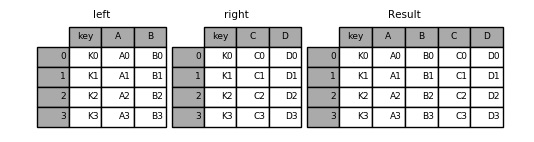

In [104]:
left = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'],
                     'A': ['A0', 'A1', 'A2', 'A3'],
                      'B': ['B0', 'B1', 'B2', 'B3']})

right = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'],
                         'C': ['C0', 'C1', 'C2', 'C3'],
                        'D': ['D0', 'D1', 'D2', 'D3']})


result = pd.merge(left, right, on='key')
result

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,A3,B3,C3,D3


Aquí hay un ejemplo más complejo con varias llaves de un join. Solo las llaves que aparecen a la izquierda y a la derecha están presentes (la intersección), como how='inner' por default.

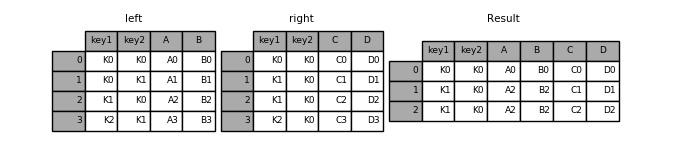

In [105]:
left = pd.DataFrame({'key1': ['K0', 'K0', 'K1', 'K2'],
                       'key2': ['K0', 'K1', 'K0', 'K1'],
                        'A': ['A0', 'A1', 'A2', 'A3'],
                        'B': ['B0', 'B1', 'B2', 'B3']})


right = pd.DataFrame({'key1': ['K0', 'K1', 'K1', 'K2'],
                          'key2': ['K0', 'K0', 'K0', 'K0'],
                         'C': ['C0', 'C1', 'C2', 'C3'],
                         'D': ['D0', 'D1', 'D2', 'D3']})


result = pd.merge(left, right, on=['key1', 'key2'])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2


El argumento de $how$ para el merge especifica cómo determinar qué llaves se incluirán en la tabla resultante. Si una combinación de teclas no aparece en las tablas izquierda o derecha, los valores en la tabla combinada serán NA. Aquí hay un resumen de cómo las opciones y sus nombres equivalentes de SQL:

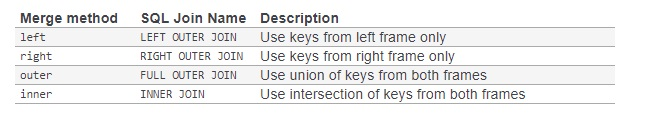

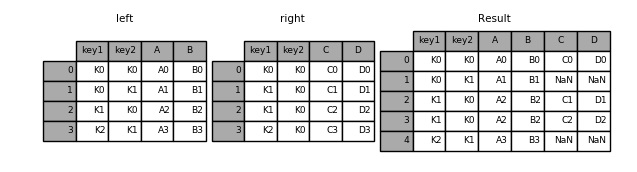

In [ ]:
result = pd.merge(left, right, how='left', on=['key1', 'key2'])

El lado opuesto!

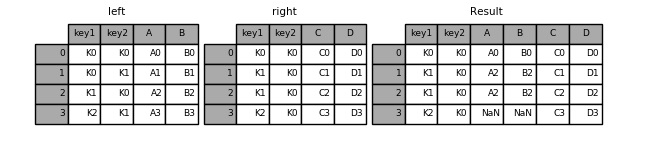

In [106]:
result = pd.merge(left, right, how='right', on=['key1', 'key2'])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2
3,K2,K0,NaN,NaN,C3,D3


La opción exterior o full

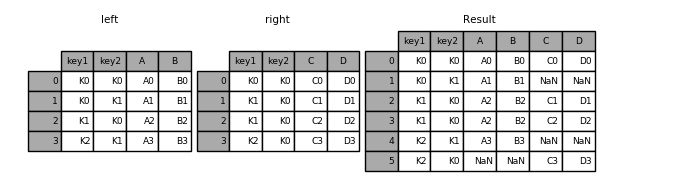

In [107]:
result = pd.merge(left, right, how='outer', on=['key1', 'key2'])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K0,K1,A1,B1,NaN,NaN
2,K1,K0,A2,B2,C1,D1
3,K1,K0,A2,B2,C2,D2
4,K2,K1,A3,B3,NaN,NaN
5,K2,K0,NaN,NaN,C3,D3


La opción interna o inner

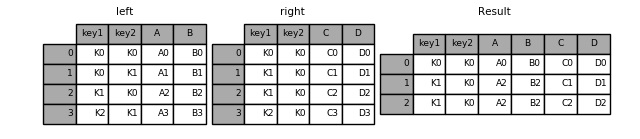

In [108]:
result = pd.merge(left, right, how='inner', on=['key1', 'key2'])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2


Un ejemplo de como combinar algunas de las funciones anteriores

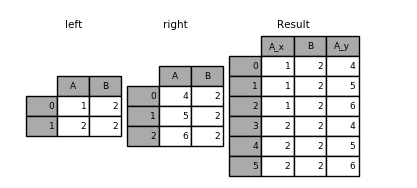

In [110]:
left = pd.DataFrame({'A': [1, 2], 'B': [2, 2]})

right = pd.DataFrame({'A': [4, 5, 6], 'B': [2, 2, 2]})

result = pd.merge(left, right, on='B', how='outer')
result

,A_x,B,A_y
0,1,2,4
1,1,2,5
2,1,2,6
3,2,2,4
4,2,2,5
5,2,2,6


In [ ]:
Checking for duplicate keys

****

****

###  pandas.DataFrame.stack


Devuelva un DataFrame o una serie remodelada que tengan un índice de múltiples niveles con uno o más niveles internos más nuevos en comparación con el DataFrame actual. Los nuevos niveles más internos se crean girando las columnas del marco de datos actual:

1) si las columnas tienen un solo nivel, la salida es una Serie.

2) Si las columnas tienen varios niveles, los nuevos niveles de índice se toman de los niveles prescritos y la salida es un DataFrame.

##### En el primer caso, las columnas tienen un solo nivel:

In [71]:
df_single_level_cols = pd.DataFrame([[0, 1], [2, 3]],
                                    index=['cat', 'dog'],
                                    columns=['weight', 'height'])
df_single_level_cols

,weight,height
cat,0,1
dog,2,3


In [72]:
df_single_level_cols.stack()

cat  weight    0
     height    1
dog  weight    2
     height    3
dtype: int64

#### El segundo caso: las columnas tienen varios niveles

In [73]:
multicol1 = pd.MultiIndex.from_tuples([('weight', 'kg'),
                                       ('weight', 'pounds')])
df_multi_level_cols1 = pd.DataFrame([[1, 2], [2, 4]],
                                    index=['cat', 'dog'],
                                   columns=multicol1)
df_multi_level_cols1

weight       
        kg pounds
cat      1      2
dog      2      4

In [74]:
df_multi_level_cols1.stack()

weight
cat kg           1
    pounds       2
dog kg           2
    pounds       4

### Valores perdidos
Es común que falten valores al apilar un marco de datos con columnas de varios niveles, ya que el marco de datos apilado generalmente tiene más valores que el marco de datos original. Los valores que faltan se rellenan con NaNs:

In [75]:
multicol2 = pd.MultiIndex.from_tuples([('weight', 'kg'),
                                       ('height', 'm')])
df_multi_level_cols2 = pd.DataFrame([[1.0, 2.0], [3.0, 4.0]],
                                  index=['cat', 'dog'],
                                   columns=multicol2)
df_multi_level_cols2

,weight,height
,kg,m
cat,1.0,2.0
dog,3.0,4.0


In [76]:
df_multi_level_cols2.stack()

height  weight
cat kg     NaN     1.0
    m      2.0     NaN
dog kg     NaN     3.0
    m      4.0     NaN

### Prescribiendo los niveles a ser apilados

El primer parámetro controla qué nivel o niveles se apilan:

In [77]:
df_multi_level_cols2.stack(0)

kg    m
cat height  NaN  2.0
    weight  1.0  NaN
dog height  NaN  4.0
    weight  3.0  NaN

In [78]:
df_multi_level_cols2.stack([0, 1])

cat  height  m     2.0
     weight  kg    1.0
dog  height  m     4.0
     weight  kg    3.0
dtype: float64

### Bajando valores perdidos
Tenga en cuenta que las filas donde faltan todos los valores se eliminan de forma predeterminada, pero este comportamiento se puede controlar a través del parámetro de la palabra clave dropna:

In [79]:
df_multi_level_cols3 = pd.DataFrame([[None, 1.0], [2.0, 3.0]],
                                    index=['cat', 'dog'],
                                    columns=multicol2)

In [80]:
df_multi_level_cols3

,weight,height
,kg,m
cat,NaN,1.0
dog,2.0,3.0


In [81]:
df_multi_level_cols3.stack(dropna=False)

height  weight
cat kg     NaN     NaN
    m      1.0     NaN
dog kg     NaN     2.0
    m      3.0     NaN

In [82]:
df_multi_level_cols3.stack(dropna=True)

height  weight
cat m      1.0     NaN
dog kg     NaN     2.0
    m      3.0     NaN

### pandas.DataFrame.unstack

Pivot un nivel de las etiquetas de índice (necesariamente jerárquicas), devolviendo un DataFrame con un nuevo nivel de etiquetas de columna cuyo nivel más interno consiste en las etiquetas de índice pivotadas.

* Si el índice no es un MultiIndex, la salida será una Serie (el análogo de la pila cuando las columnas no son un MultiIndex).

* El nivel involucrado se ordenará automáticamente.

In [83]:
index = pd.MultiIndex.from_tuples([('one', 'a'), ('one', 'b'),
                                    ('two', 'a'), ('two', 'b')])
s = pd.Series(np.arange(1.0, 5.0), index=index)
s

one  a    1.0
     b    2.0
two  a    3.0
     b    4.0
dtype: float64

In [84]:
s.unstack(level=-1)

,a,b
one,1.0,2.0
two,3.0,4.0


In [85]:
s.unstack(level=0)

,one,two
a,1.0,3.0
b,2.0,4.0


In [86]:
df = s.unstack(level=0)
df.unstack()

one  a    1.0
     b    2.0
two  a    3.0
     b    4.0
dtype: float64

### pandas.DataFrame.sample


Devuelve una muestra aleatoria de elementos

In [87]:
s = pd.Series(np.random.randn(50))
s.head()

0    0.230390
1    0.801826
2   -1.218275
3    2.217663
4    0.891346
dtype: float64

In [88]:
df = pd.DataFrame(np.random.randn(50, 4), columns=list('ABCD'))
df.head()

,A,B,C,D
0,0.731359,0.827660,-0.164450,0.830491
1,1.815064,-2.219398,0.499081,-0.220485
2,0.441209,-0.517314,0.952874,0.054120
3,0.895440,0.302587,0.485463,0.427642
4,-0.296323,0.521720,-0.272554,0.232378


In [89]:
s.sample(n=3)

42    0.700776
31   -1.421655
2    -1.218275
dtype: float64

Y un 10% aleatorio del DataFrame con reemplazo:

In [90]:
df.sample(frac=0.1, replace=True)

,A,B,C,D
11,0.942213,0.615483,1.071959,-1.271114
8,-0.397815,-0.317557,-1.309394,-0.979720
43,0.034043,0.519043,-1.555279,-1.352849
24,0.676429,0.248207,-0.213222,-0.396424
45,0.384253,-0.481463,0.160417,-0.270784


### random.sample() 

$sample()$ es una función incorporada de un módulo aleatorio en Python que devuelve una lista de longitud particular de elementos elegidos de la secuencia, es decir, lista, tupla, cadena o conjunto. Utilizado para muestreo aleatorio sin reemplazo.

In [91]:
# import random
from random import sample

# Imprime lista de elementos aleatorios de longitud dada
list1 = [1, 2, 3, 4, 5]

print(sample(list1,3))

[5, 2, 1]


In [92]:
# import random
import random

# Imprime lista de elementos aleatorios de longitud 3 de la lista dada.
list1 = [1, 2, 3, 4, 5, 6]
print("With list:", random.sample(list1, 3))

# Imprime lista de elementos aleatorios de longitud 4 de la lista dada.
string = "GeeksforGeeks"
print("With string:", random.sample(string, 4))

# Imprime lista de elementos aleatorios de longitud 4 de la lista dada.
tuple1 = ("ankit", "geeks", "computer", "science",
                   "portal", "scientist", "btech")
print("With tuple:", random.sample(tuple1, 4))

# Imprime lista de elementos aleatorios de longitud 3 de la lista dada..
set1 = {"a", "b", "c", "d", "e"}
print("With set:", random.sample(set1, 3))

With list: [3, 1, 4]
With string: ['o', 'k', 'G', 'e']
With tuple: ['scientist', 'science', 'geeks', 'ankit']
With set: ['c', 'd', 'a']


C:\Users\usuario\AppData\Local\Temp/ipykernel_9156/3038798132.py:19: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  print("With set:", random.sample(set1, 3))


* [Comparison with R / R libraries](https://pandas.pydata.org/pandas-docs/stable/getting_started/comparison/comparison_with_r.html)
* [Comparison with SQL](https://pandas.pydata.org/pandas-docs/stable/getting_started/comparison/comparison_with_sql.html)

## Próximo paso


***
<!--NAVIGATION-->
< [← Otras notas de Python](1.1_Python_repaso_y_Otros.ipynb) | [Contenido](Index.ipynb) >
***